In [120]:
import torch
import torch.nn.functional as F

In [121]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [122]:
# builds and maps each letter of the alphabet to a index
chars = sorted(list(set("".join(words)))) # alphabets (set deletes duplicates)
stoi = {s:i+1 for i,s in enumerate(chars)} # enumerate format: index n : chars[n]. enumerate returns just a enumerate object, convert to dict using dict comprehension
stoi["."] = 0 
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [123]:
# build dataset
block_size = 3 # context length (how many chars we take to predict the next)
X, Y = [], [] # inputs, label for each input
for w in words: # first 5
    context = [0] * block_size 
    for ch in w + '.': # iterate over every character in word, add . at the end of each word
        ix = stoi[ch]
        X.append(context) # stores context
        Y.append(ix) # label (index) for that char
        context = context[1:] + [ix] # removes the first index and adds index of char to context window ("slides" the context window to the right)

X = torch.tensor(X)
Y = torch.tensor(Y)


In [124]:
C = torch.randn((27,2))

In [125]:
emb = C[X]
C[X].shape

torch.Size([228146, 3, 2])

In [126]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [127]:
A = torch.cat(torch.unbind(emb, 1), 1) # creates new tensors wth new storage to unbind and concat, inefficient

In [128]:
B = emb.view(emb.shape[0],6) # same storage but does the dimensionality manipulation for us, much more efficient

In [129]:
A == B

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        ...,
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True]])

In [130]:
h = torch.tanh(B @ W1 + b1)

In [131]:
h # the hidden layer for all 32 examples

tensor([[-1.0000, -0.9533,  0.9984,  ...,  0.4613, -0.9890,  0.4674],
        [-0.9999, -0.9914, -0.7914,  ...,  0.8881, -0.8916, -0.9719],
        [-0.4222, -0.9983, -0.9987,  ...,  0.9905, -0.9068, -0.6426],
        ...,
        [-0.2127, -0.9226,  0.2855,  ..., -0.8548, -0.9817,  0.7698],
        [ 0.1208, -0.9110,  0.8552,  ..., -0.8636, -0.9927,  0.9775],
        [-0.3849,  0.8131, -0.9802,  ..., -0.9584,  0.5042, -0.1003]])

In [132]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [133]:
logits = h @ W2 + b2

In [134]:
logits.shape # the output layer

torch.Size([228146, 27])

In [135]:
# softmax
prob = logits.exp() / logits.exp().sum(1, keepdim=True)

In [136]:
prob.shape

torch.Size([228146, 27])

In [137]:
like = prob[torch.arange(228146), Y] # iterates thru each row of output, gets probability of picking the "correct character" (labels in Y)

In [138]:
loss = -like.log().mean()
loss

tensor(17.1898)

In [139]:
# full code for deterministic outcome
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [140]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [141]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [142]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(228146), Y].log().mean()
loss

tensor(19.5052)

In [143]:
# instead of softmax then calculating average nll, we can do this
F.cross_entropy(logits, Y) # for classification models (like ours)
# saves on memory (no need to create intermediate tensors like counts, prob, loss)
# more efficient backward pass (goes from having to read multiple steps of a blueprint to just one) 
# more well-behaved (prevents funky numbers when logits has a very positive number)

tensor(19.5052)

right now, loss decreases so easily because we are overfitting the data (with 3k parameters and only 32 examples, model gets used to the small batch of data very fast)

In [144]:
# on the full dataset, gradient descent is very slow as we forward, backward pass and update way more times now.
# To fix this, we create mini batches and do the same over them instead
# run gradient descent many times on a minibatch > run it less times on a full batch (efficient, accuracy is similar)
torch.randint(0, X.shape[0], (32,)) 

tensor([220350,  43626,  70502, 115067,  81349,  95160, 219535,  28657, 134399,
         87681,  99090, 176150, 113960,  48649, 207826, 205847, 125883,  90215,
         51871,  44106,  18361,  44040, 149983,  32932, 190996, 171511, 227922,
         58388, 102803, 160764, 169003, 100292])

In [145]:
for p in parameters:
    p.requires_grad=True

In [146]:
# finding suitable learning rate
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [147]:
lri = []
lossi = []
for _ in range(1000):

    # minibatch construct 
    ix = torch.randint(0, X.shape[0], (32,)) 
    # forward pass 
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) 
    

    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # update 
    lr = lrs[_]
    for p in parameters:
        p.data += -lr * p.grad 

    # track stats
    lri.append(lre[_])
    lossi.append(loss.item())

print(loss.item())

8.419657707214355


In [148]:
import matplotlib.pyplot as plt
%matplotlib inline

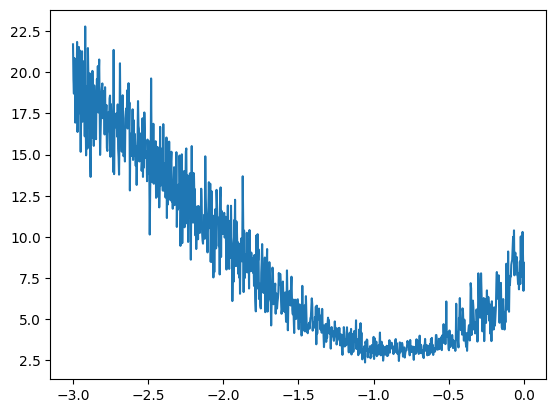

In [149]:
plt.plot(lri, lossi) # exponents of learning rate to loss after gradient descent


In [150]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y) 
loss


tensor(7.3347, grad_fn=<NllLossBackward0>)

# Final Code

the intuition of this model is very similar to that of the bigram model

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
# tune as needed for hyperparameter optimization

In [167]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [168]:
# train val test split 
# usually its 80 / 10 /10 
# train for parameter tuning, val for hyperparameter tuning, test for model accuracy validation at the end
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [169]:
for p in parameters:
  p.requires_grad = True

In [170]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lri = []
lossi = []
stepi = []

In [171]:
for i in range(100000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 50000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

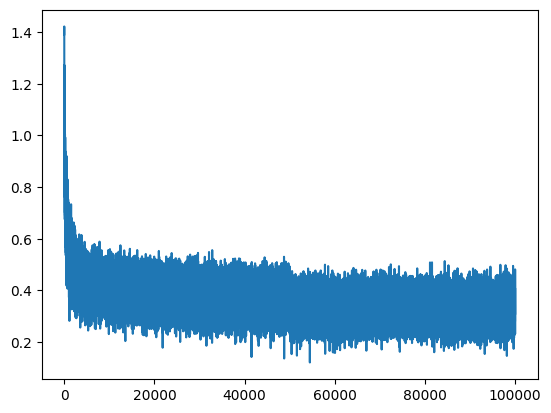

In [172]:
plt.plot(stepi, lossi)

In [173]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1782, grad_fn=<NllLossBackward0>)

In [174]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss
# note that train set and val set have similar loss, usually indicates underfitting (not enough parameters/training iterations)

tensor(2.2021, grad_fn=<NllLossBackward0>)

In [175]:
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.2111, grad_fn=<NllLossBackward0>)

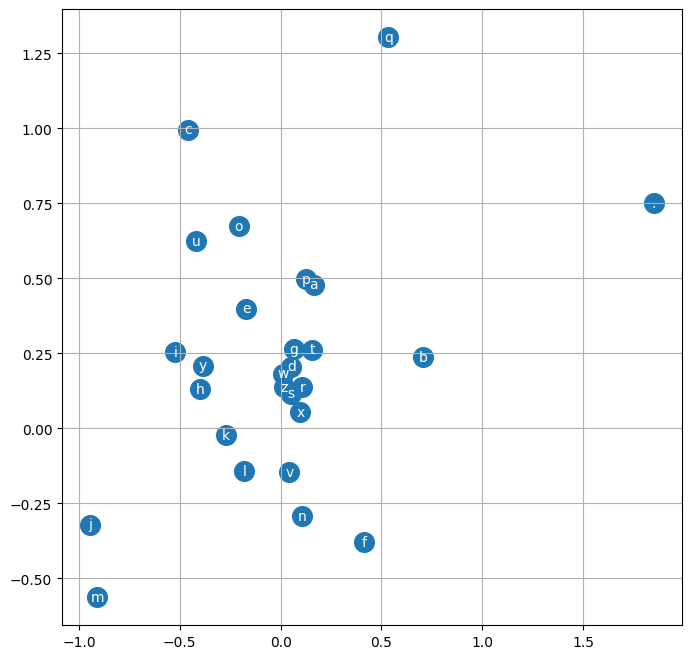

In [176]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [177]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [178]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carman.
ambrilli.
kimri.
reviyah.
cassa.
jazhuen.
delyah.
jareei.
ner.
kiahchaiiv.
kaleig.
dham.
pristerian.
shlinea.
jadiq.
wazelox.
jarynix.
kaeklinsley.
daycii.
tetteley.


In [ ]:
# the names look much better (as compared to what we did with bigram), but we can still do better C: